# 04. Feature-target EDA

wide feature 후보를 기준으로 날짜별 feature matrix를 만든다. 30일/60일 target 표본에서 결측률, split별 coverage, feature-target IC를 확인하고 05 baseline에 넘길 후보를 정리한다.

베이스라인으로 넘기는 기준은 다음 세 가지다.

- 예측 기준일에 사용할 수 있는 join rule 적용
- train, valid, test 구간에서 feature coverage 확인
- 30일/60일 target과의 관계를 horizon별로 분리해 확인

## 1. 분석 기준

| 항목 | 정의 |
|---|---|
| `wide_features` | `trd_dd` 기준 target 행에 feature를 붙인 날짜별 matrix이다. |
| `first_wide_feature_candidates` | 03에서 `use_now`, `derive_now`, `use_with_lag`로 분류한 첫 feature 후보 목록이다. |
| `asof join` | source의 `asof_date` 또는 보수적 사용 가능일이 `trd_dd` 이하인 최신 값을 붙이는 방식이다. |
| `pass_30d`, `pass_60d` | 02와 같은 `nominal_plus_15` target 표본이다. |
| `IC` | feature와 target 간 Spearman rank correlation이다. |
| `baseline_candidate` | 결측률과 split coverage 기준을 통과해 05 baseline 입력 후보로 넘길 feature이다. |

In [1]:
# C01. 환경 설정 및 경로 정의
from pathlib import Path
import os
import json
import warnings
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'targets' / 'market_vwap_targets.parquet'
CANDIDATE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'feature_readiness' / 'first_wide_feature_candidates.csv'
JOIN_RULE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'feature_readiness' / 'feature_join_rules.csv'
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
OUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'feature_target_eda'
OUT_FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'feature_target_eda'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'feature_target_eda'
DOC_DIR = PROJECT_ROOT / 'docs'

for p in [FEATURE_DIR, OUT_TABLE_DIR, OUT_FIG_DIR, REPORT_DIR, DOC_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'project_root: {PROJECT_ROOT}')
print(f'target_path exists: {TARGET_PATH.exists()}')
print(f'candidate_path exists: {CANDIDATE_PATH.exists()}')
print(f'join_rule_path exists: {JOIN_RULE_PATH.exists()}')

project_root: /mnt/hgfs/Windows/Climate
target_path exists: True
candidate_path exists: True
join_rule_path exists: True


## 2. DB 접속 및 입력 데이터 로드

In [2]:
# C02. DB 접속 및 입력 데이터 로드
def load_env_file(path: Path):
    env = {}
    if not path.exists():
        return env
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env[key.strip()] = value.strip().strip('"').strip("'")
    return env

env = {**load_env_file(PROJECT_ROOT / '.env'), **os.environ}
required = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [k for k in required if not env.get(k)]
if missing:
    raise RuntimeError(f'Missing DB env keys: {missing}')

import psycopg2
conn = psycopg2.connect(
    host=env['DB_HOST'], port=env['DB_PORT'], dbname=env['DB_NAME'],
    user=env['DB_USER'], password=env['DB_PASSWORD'],
)
print('db_connected: True')
print(f'db_name: {env["DB_NAME"]}')
print('db_driver: psycopg2')

target = pd.read_parquet(TARGET_PATH).sort_values('trd_dd').reset_index(drop=True)
target['trd_dd'] = pd.to_datetime(target['trd_dd'])
target['year'] = target['trd_dd'].dt.year

ELAPSED_CAPS = {'30d': 45, '60d': 75}
for horizon, cap in ELAPSED_CAPS.items():
    target[f'pass_{horizon}'] = (
        target[f'same_panel_{horizon}'].fillna(False)
        & target[f'target_logret_{horizon}'].notna()
        & target[f'actual_elapsed_days_{horizon}'].le(cap)
    )
target['pass_both_targets'] = target['pass_30d'] & target['pass_60d']

def assign_split(d):
    if d <= pd.Timestamp('2021-12-31'):
        return 'train'
    if d <= pd.Timestamp('2023-12-31'):
        return 'valid'
    return 'test'

target['split'] = target['trd_dd'].map(assign_split)

candidate = pd.read_csv(CANDIDATE_PATH, encoding='utf-8-sig')
join_rules = pd.read_csv(JOIN_RULE_PATH, encoding='utf-8-sig')

print(f'target rows: {len(target):,}')
print(f'candidate rows: {len(candidate):,}')
print(f"target period: {target['trd_dd'].min().date()} ~ {target['trd_dd'].max().date()}")
display(target.groupby('split').agg(rows=('trd_dd', 'size'), pass_30d=('pass_30d', 'sum'), pass_60d=('pass_60d', 'sum'), pass_both=('pass_both_targets', 'sum')).reset_index())
display(candidate.groupby(['feature_group', 'readiness_status']).size().reset_index(name='candidate_count'))

db_connected: True
db_name: allowance
db_driver: psycopg2


target rows: 2,132
candidate rows: 97
target period: 2015-01-12 ~ 2026-04-23


,split,rows,pass_30d,pass_60d,pass_both
0,test,562,540,519,519
1,train,1080,1064,1065,1055
2,valid,490,490,490,490


,feature_group,readiness_status,candidate_count
0,auction,use_with_lag,9
1,external_market,use_with_lag,10
2,market_internal,derive_now,9
3,power_epsis,use_now,46
4,weather_kma,use_now,23


## 3. Market internal feature 생성

Market feature는 target parquet의 기준일 정보에서 만든다. `future_*`, `target_logret_*` 컬럼은 feature에서 제외한다. Rolling feature는 기준일 이전 값으로 계산한다.

In [3]:
# C03. market internal feature 생성
base_cols = [
    'trd_dd', 'market_vwap', 'total_trdvol', 'total_trdval', 'n_vintages',
    'is_blended', 'vwap_range', 'min_vwap', 'max_vwap'
]
market_features = target[base_cols].copy()
market_features['mkt_log_market_vwap'] = np.log(market_features['market_vwap'])
market_features['mkt_daily_logret'] = market_features['mkt_log_market_vwap'].diff()
market_features['mkt_total_trdvol_log1p'] = np.log1p(market_features['total_trdvol'])
market_features['mkt_total_trdval_log1p'] = np.log1p(market_features['total_trdval'])
market_features['mkt_is_blended'] = market_features['is_blended'].astype(float)

rename_map = {
    'market_vwap': 'mkt_market_vwap',
    'total_trdvol': 'mkt_total_trdvol',
    'total_trdval': 'mkt_total_trdval',
    'n_vintages': 'mkt_n_vintages',
    'vwap_range': 'mkt_vwap_range',
    'min_vwap': 'mkt_min_vwap',
    'max_vwap': 'mkt_max_vwap',
}
market_features = market_features.rename(columns=rename_map)
market_features = market_features.drop(columns=['is_blended'])

for lag in [1, 5, 20, 60]:
    market_features[f'mkt_market_vwap_lag_{lag}d'] = market_features['mkt_market_vwap'].shift(lag)
    market_features[f'mkt_logret_lag_{lag}d'] = market_features['mkt_daily_logret'].shift(lag)
    market_features[f'mkt_volume_lag_{lag}d'] = market_features['mkt_total_trdvol'].shift(lag)

shifted_ret = market_features['mkt_daily_logret'].shift(1)
shifted_vol = market_features['mkt_total_trdvol_log1p'].shift(1)
for window in [5, 20, 60]:
    market_features[f'mkt_logret_mean_{window}d'] = shifted_ret.rolling(window, min_periods=max(2, window // 3)).mean()
    market_features[f'mkt_logret_vol_{window}d'] = shifted_ret.rolling(window, min_periods=max(2, window // 3)).std()
    market_features[f'mkt_volume_mean_{window}d'] = shifted_vol.rolling(window, min_periods=max(2, window // 3)).mean()
    market_features[f'mkt_volume_std_{window}d'] = shifted_vol.rolling(window, min_periods=max(2, window // 3)).std()

feature_meta_rows = []
for col in market_features.columns:
    if col == 'trd_dd':
        continue
    feature_meta_rows.append({
        'feature_name': col,
        'feature_group': 'market_internal',
        'source_table': 'data.processed.targets.market_vwap_targets',
        'source_column': col,
        'join_rule': 'target 기준일 자체 또는 기준일 이전 rolling/lag',
    })

print(f'market feature count: {len(feature_meta_rows):,}')
display(market_features.head())

market feature count: 36


,trd_dd,mkt_market_vwap,mkt_total_trdvol,mkt_total_trdval,mkt_n_vintages,mkt_vwap_range,mkt_min_vwap,mkt_max_vwap,mkt_log_market_vwap,mkt_daily_logret,mkt_total_trdvol_log1p,mkt_total_trdval_log1p,mkt_is_blended,mkt_market_vwap_lag_1d,mkt_logret_lag_1d,mkt_volume_lag_1d,mkt_market_vwap_lag_5d,mkt_logret_lag_5d,mkt_volume_lag_5d,mkt_market_vwap_lag_20d,mkt_logret_lag_20d,mkt_volume_lag_20d,mkt_market_vwap_lag_60d,mkt_logret_lag_60d,mkt_volume_lag_60d,mkt_logret_mean_5d,mkt_logret_vol_5d,mkt_volume_mean_5d,mkt_volume_std_5d,mkt_logret_mean_20d,mkt_logret_vol_20d,mkt_volume_mean_20d,mkt_volume_std_20d,mkt_logret_mean_60d,mkt_logret_vol_60d,mkt_volume_mean_60d,mkt_volume_std_60d
0,2015-01-12,"8,185.210084",1190,9740400,1,0,8185,8185,9.010084,NaN,7.082549,16.091793,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-13,"9,500.000000",50,475000,1,0,9500,9500,9.159047,0.148963,3.931826,13.071072,0.000000,"8,185.210084",NaN,"1,190.000000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-14,"9,510.000000",100,951000,1,0,9510,9510,9.160099,0.001052,4.615121,13.765270,0.000000,"9,500.000000",0.148963,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.507187,2.227898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-16,"9,610.000000",40,384400,1,0,9610,9610,9.170560,0.010460,3.713572,12.859442,0.000000,"9,510.000000",0.001052,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075007,0.104589,5.209832,1.657415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-10-07,"11,300.000000",12000,135600000,1,0,11300,11300,9.332558,0.161999,9.392745,18.725220,0.000000,"9,610.000000",0.010460,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.053492,0.082814,4.835767,1.546301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. DB source as-of feature 생성

DB source feature를 source별로 붙인다. `asof_date`가 있는 source는 `asof_date <= trd_dd` 기준을 적용한다. \
`use_with_lag` source는 source 날짜에 보수적 사용 가능일을 부여한다.

In [4]:
# C04. DB source as-of feature 생성
def table_exists(schema, table):
    q = """
    select exists (
        select 1 from information_schema.tables
        where table_schema = %s and table_name = %s
    ) as exists
    """
    return bool(pd.read_sql(q, conn, params=(schema, table))['exists'].iloc[0])

def load_source_table(source_table, cols, join_row):
    schema, table = source_table.split('.')
    if not table_exists(schema, table):
        raise RuntimeError(f'missing table: {source_table}')
    asof_col = str(join_row.get('asof_date_columns') or '').split(';')[0].strip()
    primary_col = str(join_row.get('primary_date_column') or '').strip()
    feature_col = str(join_row.get('feature_date_columns') or '').split(';')[0].strip()
    key_candidates = [asof_col, primary_col, feature_col, 'trd_dd', 'date', 'feature_date', 'feature_month']
    key_col = next((c for c in key_candidates if c and c != 'nan'), None)
    if key_col is None:
        raise RuntimeError(f'no join key for {source_table}')
    selected = [key_col] + [c for c in cols if c != key_col]
    selected_sql = ', '.join([f'"{c}"' for c in selected])
    q = f'select {selected_sql} from {schema}.{table} order by "{key_col}"'
    df = pd.read_sql(q, conn)
    df[key_col] = pd.to_datetime(df[key_col], errors='coerce')
    df = df.dropna(subset=[key_col]).copy()
    return df, key_col, asof_col

def effective_date(df, key_col, source_table, join_row):
    out = df.copy()
    freq = str(join_row.get('frequency') or '').lower()
    has_asof = str(join_row.get('asof_date_columns') or '').strip() not in ['', 'nan']
    if has_asof:
        out['effective_date'] = out[key_col]
    elif 'monthly' in freq or 'month' in freq:
        out['effective_date'] = out[key_col] + pd.offsets.MonthEnd(1)
    else:
        out['effective_date'] = out[key_col] + pd.Timedelta(days=1)
    return out

def asof_merge_features(base_dates, source_table, source_candidates, join_rules):
    join_row = join_rules.loc[join_rules['source_table'].eq(source_table)].iloc[0]
    cols = sorted(source_candidates['source_column'].dropna().unique().tolist())
    raw, key_col, asof_col = load_source_table(source_table, cols, join_row)
    raw = effective_date(raw, key_col, source_table, join_row)
    rename = dict(zip(source_candidates['source_column'], source_candidates['feature_name']))
    keep_cols = ['effective_date'] + [c for c in cols if c in raw.columns]
    feat = raw[keep_cols].rename(columns=rename)
    value_cols = [c for c in feat.columns if c != 'effective_date']
    for col in value_cols:
        feat[col] = pd.to_numeric(feat[col], errors='coerce')
    feat = feat.groupby('effective_date', as_index=False)[value_cols].mean(numeric_only=True)
    feat['effective_date'] = pd.to_datetime(feat['effective_date']).astype('datetime64[ns]')
    feat = feat.sort_values('effective_date')
    dates = base_dates[['trd_dd']].sort_values('trd_dd').copy()
    dates['trd_dd'] = pd.to_datetime(dates['trd_dd']).astype('datetime64[ns]')
    merged = pd.merge_asof(dates, feat, left_on='trd_dd', right_on='effective_date', direction='backward')
    merged = merged.drop(columns=['effective_date'])
    asof_check = {
        'source_table': source_table,
        'source_rows': int(len(raw)),
        'effective_rows': int(len(feat)),
        'feature_count': int(len(value_cols)),
        'min_effective_date': feat['effective_date'].min(),
        'max_effective_date': feat['effective_date'].max(),
    }
    return merged, asof_check

source_feature_frames = []
asof_rows = []
db_candidates = candidate.loc[~candidate['feature_group'].eq('market_internal')].copy()
for source_table, source_candidates in db_candidates.groupby('source_table'):
    merged, asof_check = asof_merge_features(target[['trd_dd']], source_table, source_candidates, join_rules)
    source_feature_frames.append(merged.set_index('trd_dd'))
    asof_rows.append(asof_check)
    for _, r in source_candidates.iterrows():
        feature_meta_rows.append({
            'feature_name': r['feature_name'],
            'feature_group': r['feature_group'],
            'source_table': r['source_table'],
            'source_column': r.get('source_column', ''),
            'join_rule': r['join_rule'],
        })

asof_summary = pd.DataFrame(asof_rows)
display(asof_summary)

,source_table,source_rows,effective_rows,feature_count,min_effective_date,max_effective_date
0,raw.commodities_monthly,136,136,3,2015-01-31,2026-04-30
1,raw.epsis_fuel_cost_monthly,132,132,15,2015-02-28,2026-01-31
2,raw.epsis_power_supply_daily,4018,4018,7,2015-01-02,2026-01-01
3,raw.epsis_power_trade_volume_monthly,132,132,20,2015-02-28,2026-01-31
4,raw.epsis_smp_monthly,132,132,4,2015-02-28,2026-01-31
5,raw.eua_daily,2912,2912,5,2015-01-03,2026-05-05
6,raw.kma_asos_weather_daily,4018,4018,12,2015-01-02,2026-01-01
7,raw.kma_asos_weather_station_daily,24108,4018,11,2015-01-02,2026-01-01
8,raw.krx_auction_monthly,80,78,9,2019-01-31,2026-04-30
9,raw.oil_daily,2844,2844,2,2015-01-03,2026-04-24


## 5. Wide feature matrix 결합

Target, market feature, DB source feature를 `trd_dd` 기준으로 결합한다. Feature matrix는 `data/processed/features/`에 parquet로 저장한다.

In [5]:
# C05. wide feature matrix 결합
feature_parts = [market_features.set_index('trd_dd')] + source_feature_frames
feature_matrix = pd.concat(feature_parts, axis=1).reset_index()
feature_matrix = feature_matrix.loc[:, ~feature_matrix.columns.duplicated()].copy()

label_cols = [
    'trd_dd', 'year', 'split', 'target_logret_30d', 'target_logret_60d',
    'pass_30d', 'pass_60d', 'pass_both_targets', 'is_blended', 'n_vintages',
    'actual_elapsed_days_30d', 'actual_elapsed_days_60d'
]
wide_features = target[label_cols].merge(feature_matrix, on='trd_dd', how='left')

feature_meta = pd.DataFrame(feature_meta_rows).drop_duplicates('feature_name').sort_values(['feature_group', 'feature_name']).reset_index(drop=True)
feature_cols = [c for c in wide_features.columns if c not in label_cols]
feature_meta = feature_meta.loc[feature_meta['feature_name'].isin(feature_cols)].copy()

GROUP_LABEL_KO = {
    'auction': 'KRX 경매',
    'external_market': '외부시장',
    'market_internal': '시장 내부',
    'power_epsis': '전력/EPSIS',
    'weather_kma': '기상/KMA',
}
SOURCE_LABEL_KO = {
    'data.processed.targets.market_vwap_targets': '시장 VWAP 타겟 데이터',
    'raw.krx_auction_monthly': 'KRX 배출권 경매',
    'raw.commodities_monthly': '원자재 월별 가격',
    'raw.eua_daily': 'EUA 일별 가격',
    'raw.oil_daily': '국제유가 일별 가격',
    'raw.epsis_fuel_cost_monthly': 'EPSIS 발전연료비',
    'raw.epsis_power_supply_daily': 'EPSIS 전력수급',
    'raw.epsis_power_trade_volume_monthly': 'EPSIS 전력거래량',
    'raw.epsis_smp_monthly': 'EPSIS SMP',
    'raw.kma_asos_weather_daily': 'KMA 전국 ASOS 기상',
    'raw.kma_asos_weather_station_daily': 'KMA 관측소 ASOS 기상',
}
FUEL_LABEL_KO = {
    'anthracite': '무연탄',
    'bituminous_coal': '유연탄',
    'lng': 'LNG',
    'nuclear': '원자력',
    'oil': '유류',
    'bio': '바이오',
    'coal_gasification': '석탄가스화',
    'coal_total': '석탄 합계',
    'fuel_cell': '연료전지',
    'hydro': '수력',
    'market_ppa_total': '시장+PPA 합계',
    'market_total': '시장 합계',
    'ocean': '해양',
    'other': '기타',
    'ppa_total': 'PPA 합계',
    'pumped_storage': '양수',
    'renewable_total': '재생에너지 합계',
    'solar': '태양광',
    'waste': '폐기물',
    'wind': '풍력',
}
COLUMN_LABEL_KO = {
    'acc_trdcnt': '거래건수',
    'acc_trdvol': '거래량',
    'auct_trd_partc_cnt': '경매 참여자 수',
    'auct_trd_qty': '경매 체결수량',
    'auct_trd_rto': '경매 체결률',
    'clsprc': '종가',
    'hgst_ord_prc': '최고 주문가격',
    'lwst_ord_prc': '최저 주문가격',
    'onewayauct_appl_qty': '단일가 경매 신청수량',
    'coal_newcastle': '뉴캐슬 석탄 가격',
    'lng_japan': '일본 LNG 가격',
    'natgas_europe': '유럽 천연가스 가격',
    'hpr': '고가',
    'lpr': '저가',
    'opr': '시가',
    'brent': '브렌트유 가격',
    'wti': 'WTI 가격',
    'day': '일자 보조값',
    'installed_capacity_mw': '설비용량(MW)',
    'minimum_demand_mw': '최저수요(MW)',
    'peak_demand_mw': '최대수요(MW)',
    'reserve_capacity_mw': '공급예비력(MW)',
    'reserve_margin_pct': '공급예비율(%)',
    'supply_capacity_mw': '공급능력(MW)',
    'blmp_krw_per_kwh': 'BLMP(원/kWh)',
    'smp_jeju_krw_per_kwh': '제주 SMP(원/kWh)',
    'smp_land_krw_per_kwh': '육지 SMP(원/kWh)',
    'smp_total_krw_per_kwh': '전국 SMP(원/kWh)',
    'avg_relative_humidity_pct': '평균 상대습도(%)',
    'avg_temp_c': '평균기온(°C)',
    'avg_wind_speed_mps': '평균 풍속(m/s)',
    'cdd18': '냉방도일 CDD18',
    'hdd18': '난방도일 HDD18',
    'is_precip_day': '강수일 여부',
    'max_temp_c': '최고기온(°C)',
    'min_temp_c': '최저기온(°C)',
    'precip_mm': '강수량(mm)',
    'solar_radiation_mj_m2': '일사량(MJ/m²)',
    'station_count': '관측소 수',
    'sunshine_hours': '일조시간',
}
MARKET_LABEL_KO = {
    'mkt_market_vwap': '시장 VWAP',
    'mkt_log_market_vwap': '시장 VWAP 로그값',
    'mkt_daily_logret': '시장 VWAP 일간 로그수익률',
    'mkt_total_trdvol': '시장 총 거래량',
    'mkt_total_trdvol_log1p': '시장 총 거래량 로그값',
    'mkt_total_trdval': '시장 총 거래대금',
    'mkt_total_trdval_log1p': '시장 총 거래대금 로그값',
    'mkt_is_blended': '복수 빈티지 거래일 여부',
    'mkt_n_vintages': '거래 빈티지 수',
    'mkt_vwap_range': '빈티지 간 VWAP 범위',
    'mkt_min_vwap': '일별 최저 빈티지 VWAP',
    'mkt_max_vwap': '일별 최고 빈티지 VWAP',
}

def _extract_window(feature_name, token):
    marker = f'_{token}_'
    if marker not in feature_name:
        return None
    tail = feature_name.split(marker, 1)[1]
    return tail.replace('d', '일')

def _db_column_label(source_column):
    source_column = str(source_column)
    if source_column in COLUMN_LABEL_KO:
        return COLUMN_LABEL_KO[source_column]
    for prefix, label in [
        ('fuel_cost_', '발전연료비'),
        ('fuel_price_', '연료가격'),
        ('heat_price_', '열량단가'),
        ('trade_volume_', '전력거래량'),
    ]:
        if source_column.startswith(prefix):
            stem = source_column[len(prefix):]
            for suffix in ['_krw_per_kwh', '_krw_per_ton', '_krw_per_kl', '_krw_per_gcal', '_gwh']:
                stem = stem.replace(suffix, '')
            return f'{label}({FUEL_LABEL_KO.get(stem, stem)})'
    return source_column

def feature_label_description(row):
    feature_name = row['feature_name']
    source_table = row.get('source_table', '')
    source_column = row.get('source_column', '')
    source_label = SOURCE_LABEL_KO.get(source_table, source_table)
    group_label = GROUP_LABEL_KO.get(row.get('feature_group', ''), row.get('feature_group', ''))
    join_rule = str(row.get('join_rule', '')).strip().rstrip('.')
    if feature_name in MARKET_LABEL_KO:
        label = MARKET_LABEL_KO[feature_name]
        desc = f'{source_label}에서 계산한 {label}입니다. 결합 기준: {join_rule}.'
        return pd.Series({'feature_label_ko': label, 'feature_description_ko': desc, 'feature_group_ko': group_label})
    for token, ko in [('lag', '전 값'), ('mean', '이동평균'), ('vol', '이동 변동성'), ('std', '이동 표준편차')]:
        window = _extract_window(feature_name, token)
        if window:
            if 'logret' in feature_name:
                base = '시장 VWAP 로그수익률'
            elif 'volume' in feature_name:
                base = '시장 거래량 로그값'
            elif 'market_vwap' in feature_name:
                base = '시장 VWAP'
            else:
                base = '시장 내부 변수'
            label = f'{base} {window} {ko}'
            desc = f'{source_label}에서 기준일 이전 값으로 계산한 {label}입니다.'
            return pd.Series({'feature_label_ko': label, 'feature_description_ko': desc, 'feature_group_ko': group_label})
    column_label = _db_column_label(source_column if source_column else feature_name.split('__')[-1])
    label = f'{source_label} {column_label}'
    desc = f'{source_table}의 `{source_column}` 값을 사용한 변수입니다. 결합 기준: {join_rule}.'
    return pd.Series({'feature_label_ko': label, 'feature_description_ko': desc, 'feature_group_ko': group_label})

feature_meta = pd.concat([feature_meta, feature_meta.apply(feature_label_description, axis=1)], axis=1)

schema = {
    'n_rows': int(len(wide_features)),
    'n_features': int(len(feature_cols)),
    'date_start': wide_features['trd_dd'].min().date().isoformat(),
    'date_end': wide_features['trd_dd'].max().date().isoformat(),
    'label_columns': label_cols,
    'feature_columns': feature_cols,
    'feature_groups': feature_meta.groupby('feature_group')['feature_name'].count().to_dict(),
}

feature_path = FEATURE_DIR / 'wide_features.parquet'
schema_path = FEATURE_DIR / 'wide_features.schema.json'
meta_path = FEATURE_DIR / 'wide_features.feature_meta.csv'
wide_features.to_parquet(feature_path, index=False)
schema_path.write_text(json.dumps(schema, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
feature_meta.to_csv(meta_path, index=False, encoding='utf-8-sig')

print(f'wide_features shape: {wide_features.shape}')
print(f'feature_count: {len(feature_cols):,}')
print(f'saved: {feature_path.relative_to(PROJECT_ROOT)}')
display(feature_meta.groupby('feature_group').agg(feature_count=('feature_name', 'size')).reset_index())

wide_features shape: (2132, 136)
feature_count: 124
saved: data/processed/features/wide_features.parquet


,feature_group,feature_count
0,auction,9
1,external_market,10
2,market_internal,36
3,power_epsis,46
4,weather_kma,23


## 6. Feature matrix coverage

전체 표본과 30일/60일 통과 표본에서 feature별 결측률을 계산한다. Split별 coverage도 함께 확인한다.

feature matrix summary


,item,value
0,rows,2132
1,features,124
2,pass_30d_rows,2094
3,pass_60d_rows,2074
4,pass_both_rows,2064


missing summary top


,feature_name,feature_label_ko,feature_group,feature_group_ko,source_table,missing_all,missing_30d,missing_60d,missing_train,missing_valid,missing_test,constant_rate,baseline_candidate_by_missing
56,epsis_power_supply_daily__minimum_demand_mw,EPSIS 전력수급 최저수요(MW),power_epsis,전력/EPSIS,raw.epsis_power_supply_daily,0.952627,0.962273,0.972035,1.000000,1.000000,0.820285,0.752475,False
75,epsis_power_trade_volume_monthly__trade_volume...,EPSIS 전력거래량 전력거래량(PPA 합계),power_epsis,전력/EPSIS,raw.epsis_power_trade_volume_monthly,0.294090,0.291786,0.295082,0.580556,0.000000,0.000000,0.036545,False
116,krx_auction_monthly__auct_trd_qty,KRX 배출권 경매 경매 체결수량,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.059441,False
113,krx_auction_monthly__acc_trdcnt,KRX 배출권 경매 거래건수,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.171911,False
114,krx_auction_monthly__acc_trdvol,KRX 배출권 경매 거래량,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.085082,False
117,krx_auction_monthly__auct_trd_rto,KRX 배출권 경매 경매 체결률,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.059441,False
118,krx_auction_monthly__clsprc,KRX 배출권 경매 종가,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.059441,False
119,krx_auction_monthly__hgst_ord_prc,KRX 배출권 경매 최고 주문가격,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.059441,False
120,krx_auction_monthly__lwst_ord_prc,KRX 배출권 경매 최저 주문가격,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.070513,False
121,krx_auction_monthly__onewayauct_appl_qty,KRX 배출권 경매 단일가 경매 신청수량,auction,KRX 경매,raw.krx_auction_monthly,0.195122,0.191022,0.193346,0.385185,0.000000,0.000000,0.199301,False


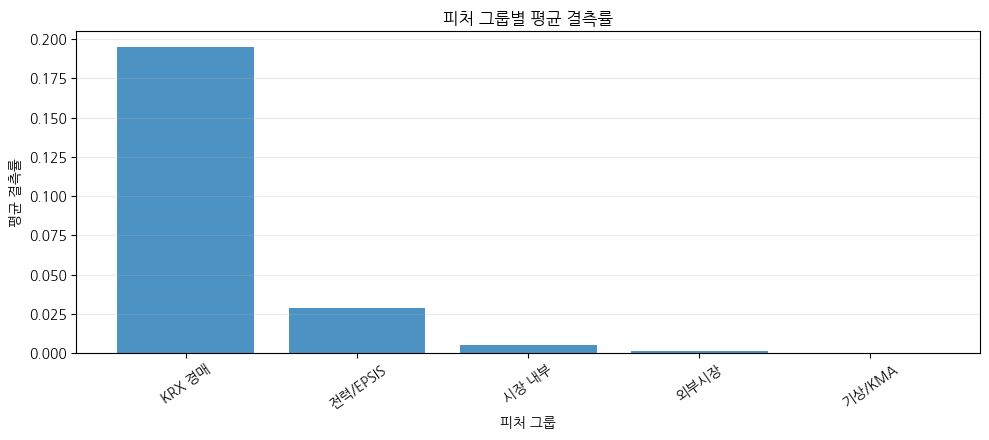

In [6]:
# C06. feature matrix coverage
missing_rows = []
for feature in feature_cols:
    meta = feature_meta.loc[feature_meta['feature_name'].eq(feature)].iloc[0]
    row = {
        'feature_name': feature,
        'feature_label_ko': meta.get('feature_label_ko', feature),
        'feature_group': meta['feature_group'],
        'feature_group_ko': meta.get('feature_group_ko', meta['feature_group']),
        'source_table': meta['source_table'],
        'missing_all': wide_features[feature].isna().mean(),
        'missing_30d': wide_features.loc[wide_features['pass_30d'], feature].isna().mean(),
        'missing_60d': wide_features.loc[wide_features['pass_60d'], feature].isna().mean(),
        'missing_train': wide_features.loc[wide_features['split'].eq('train'), feature].isna().mean(),
        'missing_valid': wide_features.loc[wide_features['split'].eq('valid'), feature].isna().mean(),
        'missing_test': wide_features.loc[wide_features['split'].eq('test'), feature].isna().mean(),
        'constant_rate': wide_features[feature].value_counts(normalize=True, dropna=True).iloc[0] if wide_features[feature].notna().any() else np.nan,
    }
    missing_rows.append(row)
missing_summary = pd.DataFrame(missing_rows)

feature_matrix_summary = pd.DataFrame([
    {'item': 'rows', 'value': len(wide_features)},
    {'item': 'features', 'value': len(feature_cols)},
    {'item': 'pass_30d_rows', 'value': int(wide_features['pass_30d'].sum())},
    {'item': 'pass_60d_rows', 'value': int(wide_features['pass_60d'].sum())},
    {'item': 'pass_both_rows', 'value': int(wide_features['pass_both_targets'].sum())},
])

missing_summary['baseline_candidate_by_missing'] = (
    missing_summary[['missing_30d', 'missing_60d', 'missing_train', 'missing_valid', 'missing_test']].max(axis=1).le(0.30)
    & missing_summary['constant_rate'].lt(0.99).fillna(False)
)

print('feature matrix summary')
display(feature_matrix_summary)
print('missing summary top')
display(missing_summary.sort_values('missing_all', ascending=False).head(20))

feature_matrix_summary.to_csv(OUT_TABLE_DIR / 'feature_matrix_summary.csv', index=False, encoding='utf-8-sig')
missing_summary.to_csv(OUT_TABLE_DIR / 'feature_missing_summary.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 4.5))
group_missing = missing_summary.groupby('feature_group_ko')['missing_all'].mean().sort_values(ascending=False)
ax.bar(group_missing.index, group_missing.values, color='tab:blue', alpha=0.8)
ax.set_title('피처 그룹별 평균 결측률')
ax.set_ylabel('평균 결측률')
ax.set_xlabel('피처 그룹')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'missingness_by_group.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Feature-target IC

30일/60일 target별 Pearson correlation과 Spearman IC를 계산한다. Split별 IC를 함께 보며, 전체 기간에서만 강한 feature를 구분한다.

,타겟 기간,피처 라벨,피처명,피처 그룹,관측치 수,전체 Spearman IC,train IC,valid IC,test IC
0,30d,EPSIS 전력수급 최저수요(MW),epsis_power_supply_daily__minimum_demand_mw,전력/EPSIS,79,0.453346,NaN,NaN,0.453346
1,30d,EPSIS 발전연료비 발전연료비(LNG),epsis_fuel_cost_monthly__fuel_cost_lng_krw_per...,전력/EPSIS,2094,-0.218988,-0.029812,0.037938,-0.439148
2,30d,EPSIS 발전연료비 열량단가(LNG),epsis_fuel_cost_monthly__heat_price_lng_krw_pe...,전력/EPSIS,2094,-0.218816,-0.030952,0.044672,-0.462694
3,30d,EPSIS 전력거래량 전력거래량(원자력),epsis_power_trade_volume_monthly__trade_volume...,전력/EPSIS,2094,-0.217080,-0.249453,-0.143083,-0.374743
4,30d,EPSIS SMP 전국 SMP(원/kWh),epsis_smp_monthly__smp_total_krw_per_kwh,전력/EPSIS,2094,-0.199992,0.048234,0.020113,-0.232468
5,30d,EPSIS SMP 육지 SMP(원/kWh),epsis_smp_monthly__smp_land_krw_per_kwh,전력/EPSIS,2094,-0.196516,0.051111,0.041712,-0.230896
6,30d,KMA 전국 ASOS 기상 냉방도일 CDD18,kma_asos_weather_daily__cdd18,기상/KMA,2094,0.196231,0.204167,0.182000,0.197952
7,30d,KMA 관측소 ASOS 기상 냉방도일 CDD18,kma_asos_weather_station_daily__cdd18,기상/KMA,2094,0.196231,0.204167,0.182000,0.197952
8,30d,EPSIS 전력거래량 전력거래량(수력),epsis_power_trade_volume_monthly__trade_volume...,전력/EPSIS,2094,0.194794,0.340631,-0.052329,0.183112
9,30d,EPSIS 전력거래량 전력거래량(폐기물),epsis_power_trade_volume_monthly__trade_volume...,전력/EPSIS,2094,0.192228,0.036978,NaN,0.269170


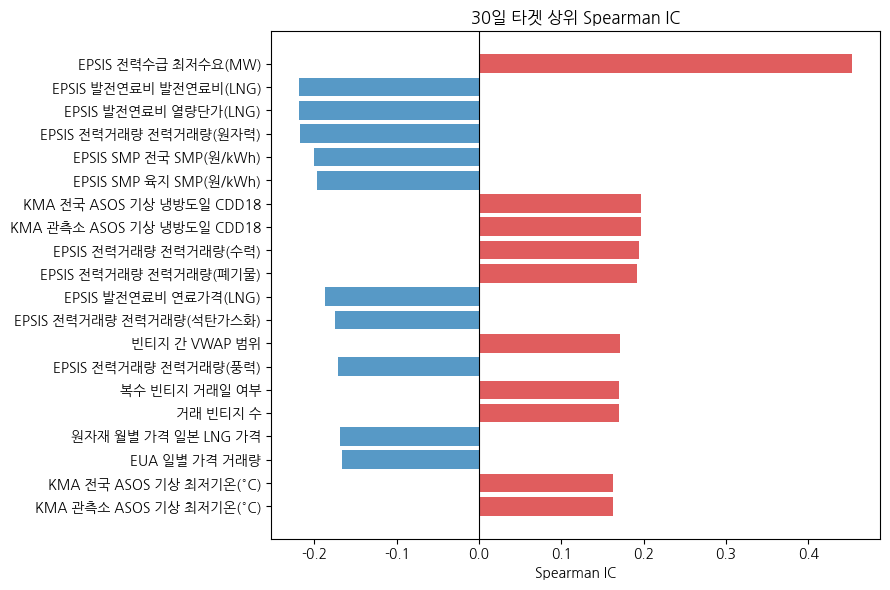

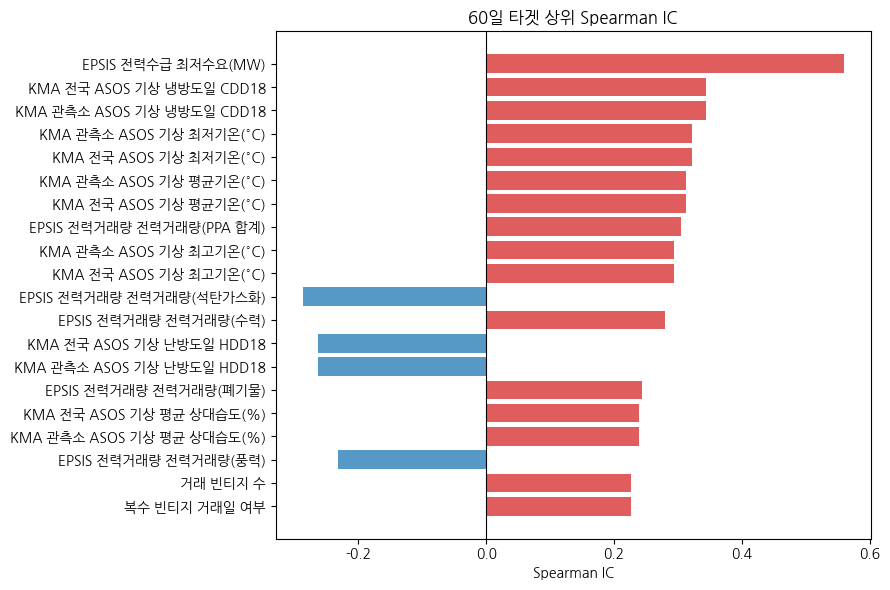

In [7]:
# C07. feature-target IC
def safe_corr(x, y, method):
    valid = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 30:
        return np.nan
    if x.loc[valid].nunique() < 2 or y.loc[valid].nunique() < 2:
        return np.nan
    return x.loc[valid].corr(y.loc[valid], method=method)

ic_rows = []
for horizon in ['30d', '60d']:
    target_col = f'target_logret_{horizon}'
    pass_col = f'pass_{horizon}'
    base_mask = wide_features[pass_col]
    for feature in feature_cols:
        meta = feature_meta.loc[feature_meta['feature_name'].eq(feature)].iloc[0]
        row = {
            'horizon': horizon,
            'feature_name': feature,
            'feature_label_ko': meta.get('feature_label_ko', feature),
            'feature_group': meta['feature_group'],
            'feature_group_ko': meta.get('feature_group_ko', meta['feature_group']),
            'source_table': meta['source_table'],
            'n_obs': int((base_mask & wide_features[feature].notna() & wide_features[target_col].notna()).sum()),
            'pearson_all': safe_corr(wide_features.loc[base_mask, feature], wide_features.loc[base_mask, target_col], 'pearson'),
            'spearman_all': safe_corr(wide_features.loc[base_mask, feature], wide_features.loc[base_mask, target_col], 'spearman'),
        }
        for split in ['train', 'valid', 'test']:
            mask = base_mask & wide_features['split'].eq(split)
            row[f'spearman_{split}'] = safe_corr(wide_features.loc[mask, feature], wide_features.loc[mask, target_col], 'spearman')
        split_vals = [row.get(f'spearman_{s}') for s in ['train', 'valid', 'test']]
        valid_split_vals = [v for v in split_vals if pd.notna(v)]
        row['split_ic_std'] = float(np.nanstd(valid_split_vals)) if valid_split_vals else np.nan
        row['abs_spearman_all'] = abs(row['spearman_all']) if pd.notna(row['spearman_all']) else np.nan
        ic_rows.append(row)

feature_target_ic = pd.DataFrame(ic_rows)
feature_target_ic = feature_target_ic.sort_values(['horizon', 'abs_spearman_all'], ascending=[True, False]).reset_index(drop=True)
feature_target_ic.to_csv(OUT_TABLE_DIR / 'feature_target_ic.csv', index=False, encoding='utf-8-sig')

feature_target_ic_display = feature_target_ic.groupby('horizon').head(15)[[
    'horizon', 'feature_label_ko', 'feature_name', 'feature_group_ko', 'n_obs',
    'spearman_all', 'spearman_train', 'spearman_valid', 'spearman_test'
]].rename(columns={
    'horizon': '타겟 기간',
    'feature_label_ko': '피처 라벨',
    'feature_name': '피처명',
    'feature_group_ko': '피처 그룹',
    'n_obs': '관측치 수',
    'spearman_all': '전체 Spearman IC',
    'spearman_train': 'train IC',
    'spearman_valid': 'valid IC',
    'spearman_test': 'test IC',
})
display(feature_target_ic_display)

for horizon in ['30d', '60d']:
    top = feature_target_ic.loc[feature_target_ic['horizon'].eq(horizon)].dropna(subset=['spearman_all']).head(20).copy()
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = np.where(top['spearman_all'].ge(0), 'tab:red', 'tab:blue')
    ax.barh(top['feature_label_ko'][::-1], top['spearman_all'][::-1], color=colors[::-1], alpha=0.75)
    ax.axvline(0, color='black', linewidth=0.8)
    horizon_label = {'30d': '30일', '60d': '60일'}[horizon]
    ax.set_title(f'{horizon_label} 타겟 상위 Spearman IC')
    ax.set_xlabel('Spearman IC')
    fig.tight_layout()
    fig.savefig(OUT_FIG_DIR / f'top_feature_ic_{horizon}.png', dpi=160, bbox_inches='tight')
    plt.show()

## 8. Feature group 요약 및 baseline 후보

결측률, 상수 비율, IC를 함께 사용해 05 baseline의 첫 입력 후보를 정리한다. 이 단계의 후보는 모델 입력 시작점이며, 실제 사용 여부는 05의 walk-forward 성능으로 확인한다.

feature group summary


,feature_group,feature_group_ko,feature_count,baseline_candidate_count,mean_missing_all,mean_abs_ic_30d,mean_abs_ic_60d,max_abs_ic
3,power_epsis,전력/EPSIS,46,43,0.028652,0.112360,0.130133,0.559204
2,market_internal,시장 내부,36,36,0.004964,0.071529,0.098818,0.226932
4,weather_kma,기상/KMA,23,22,0.000000,0.103587,0.197674,0.343175
1,external_market,외부시장,10,10,0.001126,0.102237,0.091929,0.185437
0,auction,KRX 경매,9,0,0.195122,0.094932,0.132944,0.210586


baseline feature set preview


,feature_name,feature_label_ko,feature_group,feature_group_ko,source_table,missing_30d,missing_60d,missing_train,missing_valid,missing_test,abs_ic_30d,abs_ic_60d,max_abs_ic
105,kma_asos_weather_station_daily__cdd18,KMA 관측소 ASOS 기상 냉방도일 CDD18,weather_kma,기상/KMA,raw.kma_asos_weather_station_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.196231,0.343175,0.343175
93,kma_asos_weather_daily__cdd18,KMA 전국 ASOS 기상 냉방도일 CDD18,weather_kma,기상/KMA,raw.kma_asos_weather_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.196231,0.343175,0.343175
109,kma_asos_weather_station_daily__min_temp_c,KMA 관측소 ASOS 기상 최저기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_station_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.162394,0.321726,0.321726
97,kma_asos_weather_daily__min_temp_c,KMA 전국 ASOS 기상 최저기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.162395,0.321723,0.321723
103,kma_asos_weather_station_daily__avg_temp_c,KMA 관측소 ASOS 기상 평균기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_station_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.155457,0.312538,0.312538
91,kma_asos_weather_daily__avg_temp_c,KMA 전국 ASOS 기상 평균기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.155449,0.312533,0.312533
108,kma_asos_weather_station_daily__max_temp_c,KMA 관측소 ASOS 기상 최고기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_station_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.142749,0.293139,0.293139
96,kma_asos_weather_daily__max_temp_c,KMA 전국 ASOS 기상 최고기온(°C),weather_kma,기상/KMA,raw.kma_asos_weather_daily,0.000000,0.000000,0.000000,0.000000,0.000000,0.142741,0.293134,0.293134
64,epsis_power_trade_volume_monthly__trade_volume...,EPSIS 전력거래량 전력거래량(석탄가스화),power_epsis,전력/EPSIS,raw.epsis_power_trade_volume_monthly,0.000000,0.000000,0.003704,0.000000,0.000000,0.175324,0.287035,0.287035
67,epsis_power_trade_volume_monthly__trade_volume...,EPSIS 전력거래량 전력거래량(수력),power_epsis,전력/EPSIS,raw.epsis_power_trade_volume_monthly,0.000000,0.000000,0.003704,0.000000,0.000000,0.194794,0.279164,0.279164


baseline feature count: 111


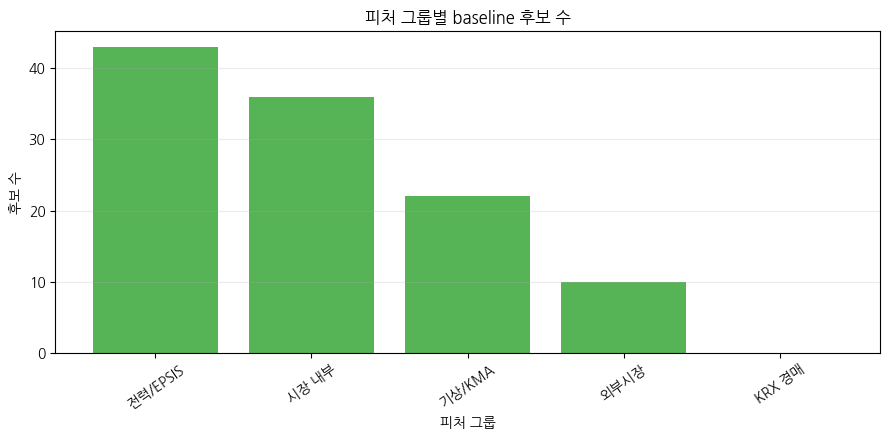

In [8]:
# C08. feature group 요약 및 baseline 후보
ic_wide = (
    feature_target_ic
    .pivot_table(index='feature_name', columns='horizon', values='abs_spearman_all', aggfunc='max')
    .rename(columns={'30d': 'abs_ic_30d', '60d': 'abs_ic_60d'})
    .reset_index()
)
missing_with_ic = missing_summary.merge(ic_wide, on='feature_name', how='left')
missing_with_ic['max_abs_ic'] = missing_with_ic[['abs_ic_30d', 'abs_ic_60d']].max(axis=1)
missing_with_ic['baseline_candidate'] = (
    missing_with_ic['baseline_candidate_by_missing']
    & missing_with_ic['max_abs_ic'].notna()
)

missing_with_ic['drop_reason'] = np.select(
    [
        missing_with_ic[['missing_30d', 'missing_60d', 'missing_train', 'missing_valid', 'missing_test']].max(axis=1).gt(0.30),
        missing_with_ic['constant_rate'].ge(0.99).fillna(False),
        missing_with_ic['max_abs_ic'].isna(),
    ],
    ['missing_over_30pct_in_target_or_split', 'near_constant', 'ic_not_available'],
    default='review'
)
feature_drop_candidates = missing_with_ic.loc[~missing_with_ic['baseline_candidate']].copy()

feature_group_summary = (
    missing_with_ic
    .groupby(['feature_group', 'feature_group_ko'])
    .agg(
        feature_count=('feature_name', 'size'),
        baseline_candidate_count=('baseline_candidate', 'sum'),
        mean_missing_all=('missing_all', 'mean'),
        mean_abs_ic_30d=('abs_ic_30d', 'mean'),
        mean_abs_ic_60d=('abs_ic_60d', 'mean'),
        max_abs_ic=('max_abs_ic', 'max'),
    )
    .reset_index()
    .sort_values('baseline_candidate_count', ascending=False)
)

baseline_feature_set = missing_with_ic.loc[missing_with_ic['baseline_candidate'], [
    'feature_name', 'feature_label_ko', 'feature_group', 'feature_group_ko', 'source_table', 'missing_30d', 'missing_60d',
    'missing_train', 'missing_valid', 'missing_test', 'abs_ic_30d', 'abs_ic_60d', 'max_abs_ic'
]].sort_values('max_abs_ic', ascending=False)

feature_group_summary.to_csv(OUT_TABLE_DIR / 'feature_group_summary.csv', index=False, encoding='utf-8-sig')
feature_drop_candidates.to_csv(OUT_TABLE_DIR / 'feature_drop_candidates.csv', index=False, encoding='utf-8-sig')
baseline_feature_set.to_csv(OUT_TABLE_DIR / 'baseline_feature_set_v1.csv', index=False, encoding='utf-8-sig')

print('feature group summary')
display(feature_group_summary)
print('baseline feature set preview')
display(baseline_feature_set.head(30))
print(f'baseline feature count: {len(baseline_feature_set):,}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(feature_group_summary['feature_group_ko'], feature_group_summary['baseline_candidate_count'], color='tab:green', alpha=0.8)
ax.set_title('피처 그룹별 baseline 후보 수')
ax.set_ylabel('후보 수')
ax.set_xlabel('피처 그룹')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'baseline_candidate_count_by_group.png', dpi=160, bbox_inches='tight')
plt.show()